# ProCatModel Overview and Tutorial

This notebook serves as a brief overview of the capabilities of the ProCatModel class. This notebook specifically goes over the basic functionalities of the class for constructing, solving, and extrcting state information from the class. All of the examples below use a simple A<->B reaction network.

In [1]:
# Import necessary packages
import numpy as np
import torch
import random
import matplotlib.pyplot as plt
from pyomo.environ import SolverFactory, value
import matplotlib as mpl

# Import ProCatModel package
import sys
import os
parent_dir = os.path.abspath(os.path.join(os.path.dirname('ProCatPy'), '..'))
sys.path.insert(0, parent_dir)
from ProCatPy.ProCatSystem import ProCatModel

# Disable warnings due to GP model standardization differences
import warnings
warnings.filterwarnings("ignore")

C:\Users\jflory\AppData\Local\anaconda3\envs\CatEnvBackup\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


First, let's create an instance of the ProCatModel class that we can use later. When calling ProCatModel, the system model is taken from the System_Model.py file in the same directory as the working file. This System_Model.py file contains all of the information necessary to construct the model along with a function for extracting the steady-state data into a more usable form.

To call the model, we also need to assign the binding energy scaling parameters, $\gamma$ and $\delta$, as well as the activation energy parameters $\alpha$ and $\beta$. Since we have 2 surface species, $A^*$ and $B^*$, we need 1 $\gamma$ and $\delta$. Since we have 1 surface reaction, $A^*$ <-> $B^*$, we also need 1 $\alpha$ and $\beta$ to fully define the model.

In [2]:
BEParams = np.array([[2], # gamma
                     [1.4]]) # delta
EaParams = np.array([[0.6], # alpha
                     [1]]) # beta

dcn = ProCatModel(BEParams,EaParams)

With the ProCatModel now defined, let's run an a simulation for an example control program. First, we need to define energy bounds for this system to ensure our control program doesn't go beyond our predetermined limits. Then, we need to define the control program parameters and provide them to the system.

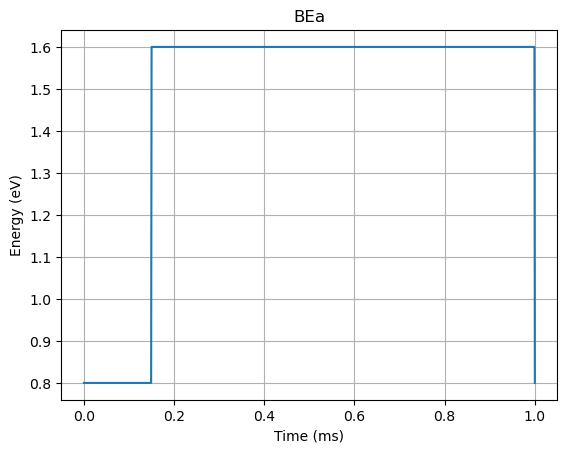

In [3]:
# Define the upper and lower limits of the control program 
ebounds = np.array([0.8,2.0])

# Define the number of basis signals used and their shape
dcn.SetEnergyParams(ebounds,1,'Square')

# Define the control program parameter values
eparams = {'Amplitude':[1],
           'DutyCycle':[0.15],
           'Frequency':[1e3],
           'Offset': 1.1,
            }

# Set the energy program values
# To display a copy of the control program, set printSignals to True
dcn.SetSignalParams(eparams,printSignals=True)

Now that we have the model parameters defined and the control program constructed, we can build our model and solve for the cyclic steady-state concentrations.

Note: By default, IPOPT's default linear solver, MUMPS, does not work well on harder, more complex problems. For this simple system this is not an issue, but more complex systems will require better solvers such as MA27.

In [4]:
# Solve for cyclic steadt-state using the above control program and parameters
# To enable the solver ouput, set tee to True
dcn.solveBVP(100,'F',tee = False)

Now that we have solved for cyclic steady-state, we can visualize the state of the system over time to see how the system responds to the control program.

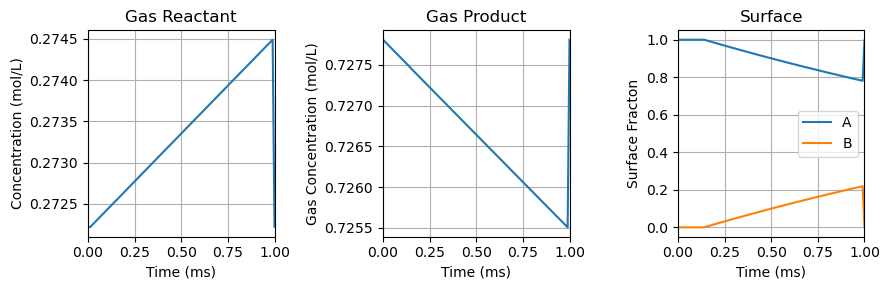

In [5]:
# Extract relevant data from the simulation results
t = dcn.tdata
CAg = dcn.CAg
CA = dcn.CA
CB = dcn.CB
CBg = dcn.CBg

# Plot reactant, gas, and surface behavior
fig, ax = plt.subplots(1,3,figsize = (9,3))
ax[0].plot(t,CAg)
ax[0].set_xlabel('Time (ms)')
ax[0].set_ylabel('Concentration (mol/L)')
ax[0].set_title('Gas Reactant')
ax[0].grid()
ax[0].set_xlim([0,1])

ax[1].plot(t,CBg)
ax[1].set_xlabel('Time (ms)')
ax[1].set_ylabel('Gas Concentration (mol/L)')
ax[1].set_title('Gas Product')
ax[1].grid()
ax[1].set_xlim([0,1])

ax[2].plot(t,CA)
ax[2].plot(t,CB)
ax[2].set_xlabel('Time (ms)')
ax[2].set_ylabel('Surface Fracton')
ax[2].set_title('Surface')
ax[2].grid()
ax[2].set_xlim([0,1])
ax[2].legend(['A','B'])
fig.tight_layout()

We can also look at the overall performance of this system. Let's look at the average turnover frequency (avTOF) during the cycle.

In [6]:
# Calculate the TOF for production of CBg
avTOFB = dcn.calc_TOF(dcn.CBg)

# Display the avTOF
print(f'avTOF: {avTOFB:4.3e}')

avTOF: 2.189e+02


Although we have the avTOF for this dynamic system, we need a baseline to compare it to. Let's quickly run some static simulations to find the best baseline performance so we can make a better comparison. 

In [7]:
# How many simulations to conduct and the energy limits for these simulations
no = 51
ebounds = np.array([0.7,1.6])

# Record the static binding energy, CBg concentration, and TOF
Offsets = np.linspace(ebounds[0],ebounds[1],no)
sTOF = np.zeros([no])

# Simulate the system under different static conditions
dcn = ProCatModel(BEParams,EaParams)
dcn.SetEnergyParams(ebounds,1,'Square')

for i in range(no):

    # Set parameters for this simulation
    # Setting Amplitude / DutyCycle to 0 removes dynamics
    # Frequency does not impact performance but does impact stability
    eparams = {'Amplitude':[0.0],
           'DutyCycle':[0.0],
           'Frequency':[1e-2],
           'Offset': Offsets[i],
           }

    dcn.SetSignalParams(eparams,False)
    dcn.solveBVP(1,'F',False)
    sTOF[i] = dcn.calc_TOF(dcn.CBg)

# Determine maximum TOF
sindex = np.argmax(sTOF)
Oopt = Offsets[sindex]
TOFopt = sTOF[sindex]

print(f'Optimal Performance: {TOFopt:4.3e} at {Oopt:2.1f}')

Optimal Performance: 9.062e-02 at 1.1


Let's make a volcano plot from these results to show the optimal static performance. Now that we have the optimum, we can also compute the efficiency factor. 

Efficiency Factor: 3.38


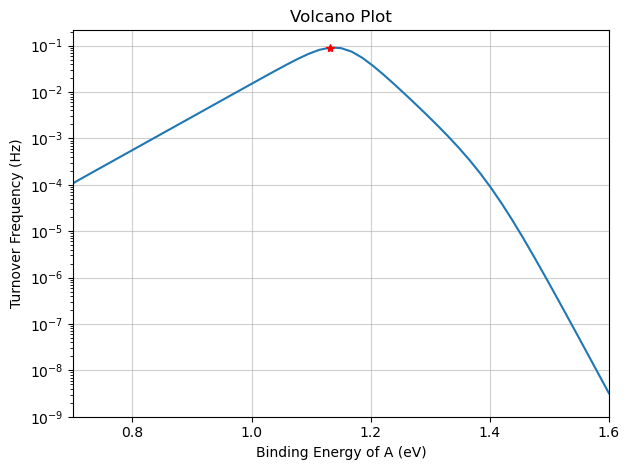

In [9]:
# Construct volcano plot
fig, ax = plt.subplots()
ax.semilogy(Offsets,sTOF)
ax.plot([Oopt],[TOFopt],'r*')
ax.set_xlabel('Binding Energy of A (eV)')
ax.set_ylabel('Turnover Frequency (Hz)')
ax.set_title('Volcano Plot')
ax.set_xlim([0.7,1.6])
ax.set_ylim([1e-9,None])
ax.grid(alpha = 0.6)
fig.tight_layout()

EF = np.log10(avTOFB/TOFopt)
print(f'Efficiency Factor: {EF:3.2f}')

Even by picking arbitrary signal parameters, we can already see our turnover frequency increase by over 3 orders of magnitude by going from a static to a dynamic system. 